#### Guilherme Martins Silva - 10417140
#### Enzo Ribeiro - 10418262
#### Pedro Nogueira Ribeiro - 10324924
# Análise Exploratória (NLP) do Corpus COSO ERM 2017

Projeto: **Agente Especialista em GRC** &ndash; Universidade Presbiteriana Mackenzie &ndash; Inteligência Artificial.

O "dataset" deste projeto não é um dataframe tabular, e sim um corpus textual: o documento
oficial *Enterprise Risk Management &ndash; Integrating with Strategy and Performance* (COSO, 2017).
Por isso, a análise exploratória é conduzida com técnicas de Processamento de Linguagem
Natural (PLN): estatísticas de corpus, limpeza/normalização de texto, frequência de termos,
TF-IDF e extração da estrutura temática (5 componentes / 20 princípios) do framework.


In [1]:
import re
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import nltk
import pandas as pd
from nltk.corpus import stopwords, words as nltk_words
from nltk.tokenize import sent_tokenize, word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer

%matplotlib inline


In [2]:
CORPUS_PATH = Path("coso_erm_2017.txt")

for resource, pkg in [
    ("tokenizers/punkt", "punkt"),
    ("tokenizers/punkt_tab", "punkt_tab"),
    ("corpora/stopwords", "stopwords"),
    ("corpora/words", "words"),
]:
    try:
        nltk.data.find(resource)
    except LookupError:
        nltk.download(pkg, quiet=True)

english_vocab = set(w.lower() for w in nltk_words.words())


## 1. Carga do corpus

In [3]:
raw_text = CORPUS_PATH.read_text(encoding="utf-8")
print(f"Caracteres (bruto): {len(raw_text):,}")
print(raw_text[:400])


Caracteres (bruto): 372,522
eBook ISBN: 978-1-94549-886-2

©2017 All Rights Reserved. No part of this publication may be reproduced,
redistributed, transmitted, or displayed in any form or by any means without
written permission COSO.
break



Table of Contents
1. Executive Summary

2. Framework

3. Appendices
Executive Summary
break

This project was commissioned by the Committee of Sponsoring
Organizations of the Tread


## 2. Limpeza e preparação do texto

A extração do PDF original para `.txt` introduziu dois problemas:

1. Marcadores residuais de paginação (a palavra isolada `break` em linhas próprias).
2. Perda do ligature tipográfico **"fi"**: a sequência de caracteres "fi" é sistematicamente
   substituída por um espaço em branco (ex.: `"Certified"` vira `"Certi ed"`; `"Defines"` vira
   `"De nes"`; `"Identifies"` vira `"Identi es"`).

O segundo problema é corrigido com uma heurística: para cada par de palavras separadas por um
único espaço, testamos se a fusão com "fi" inserido forma uma palavra válida do dicionário inglês
(`nltk.words`, com tratamento de flexões simples), e confirmamos que a versão sem espaço NÃO é,
ela própria, uma palavra válida &ndash; evitando fusões por coincidência.


In [4]:
def known_word(word: str) -> bool:
    w = word.lower()
    if w in english_vocab:
        return True
    if w.endswith("ies") and (w[:-3] + "y") in english_vocab:  # identifies -> identify
        return True
    for suffix in ("es", "ed", "s", "ing"):
        if w.endswith(suffix) and w[: -len(suffix)] in english_vocab:
            return True
    return False


def fix_broken_fi_ligature(text: str) -> tuple[str, int]:
    pattern = re.compile(r"\b([A-Za-z]{2,})[ ]([a-z]{1,6})\b")
    fixes = 0

    def repl(match):
        nonlocal fixes
        left, right = match.group(1), match.group(2)
        candidate = f"{left}fi{right}"
        merged = f"{left}{right}"
        if known_word(candidate) and merged.lower() not in english_vocab:
            fixes += 1
            return candidate
        return match.group(0)

    return pattern.sub(repl, text), fixes


def clean_text(text: str) -> tuple[str, dict]:
    no_breaks, n_breaks = re.subn(r"(?m)^\s*break\s*$\n?", "", text)
    fixed, n_fixes = fix_broken_fi_ligature(no_breaks)
    normalized = re.sub(r"[ \t]+", " ", fixed)
    normalized = re.sub(r"\n{3,}", "\n\n", normalized).strip()
    return normalized, {"linhas_break_removidas": n_breaks, "palavras_fi_corrigidas": n_fixes}


clean, cleaning_stats = clean_text(raw_text)
cleaning_stats


{'linhas_break_removidas': 52, 'palavras_fi_corrigidas': 338}

## 3. Estatísticas gerais do corpus (após limpeza)

In [5]:
sentences = sent_tokenize(clean)
tokens_all = word_tokenize(clean)
tokens_alpha = [t for t in tokens_all if t.isalpha()]
vocab = set(t.lower() for t in tokens_alpha)
words_per_sentence = [len(word_tokenize(s)) for s in sentences]

stats = {
    "num_caracteres": len(clean),
    "num_sentencas": len(sentences),
    "num_tokens_total": len(tokens_all),
    "num_tokens_alfabeticos": len(tokens_alpha),
    "tamanho_vocabulario": len(vocab),
    "diversidade_lexica_ttr": round(len(vocab) / len(tokens_alpha), 4),
    "media_palavras_por_sentenca": round(sum(words_per_sentence) / len(words_per_sentence), 2),
    "media_caracteres_por_palavra": round(sum(len(t) for t in tokens_alpha) / len(tokens_alpha), 2),
}
pd.DataFrame([stats]).T.rename(columns={0: "valor"})


,valor
num_caracteres,366662.0000
num_sentencas,2492.0000
num_tokens_total,61241.0000
num_tokens_alfabeticos,52919.0000
tamanho_vocabulario,3879.0000
diversidade_lexica_ttr,0.0733
media_palavras_por_sentenca,24.5800
media_caracteres_por_palavra,5.5800


## 4. Frequência de termos (stopwords removidas)

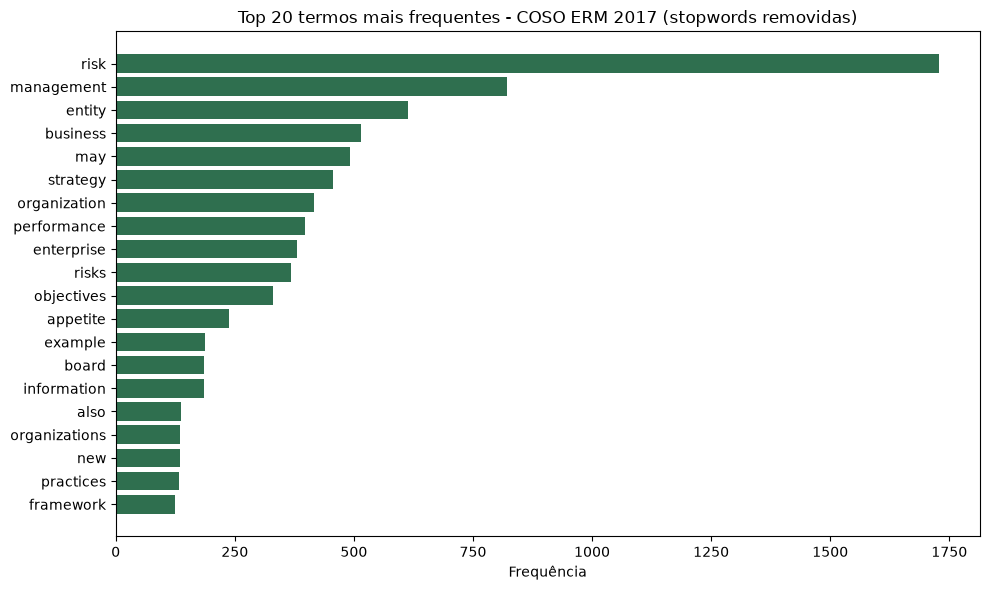

In [6]:
stop_set = set(stopwords.words("english"))
tokens_freq = [t for t in word_tokenize(clean.lower()) if t.isalpha() and t not in stop_set and len(t) > 2]
freq = Counter(tokens_freq).most_common(20)

words_, counts_ = zip(*freq)
plt.figure(figsize=(10, 6))
plt.barh(words_[::-1], counts_[::-1], color="#2f6f4f")
plt.title("Top 20 termos mais frequentes - COSO ERM 2017 (stopwords removidas)")
plt.xlabel("Frequência")
plt.tight_layout()
plt.show()


## 5. TF-IDF por parágrafo

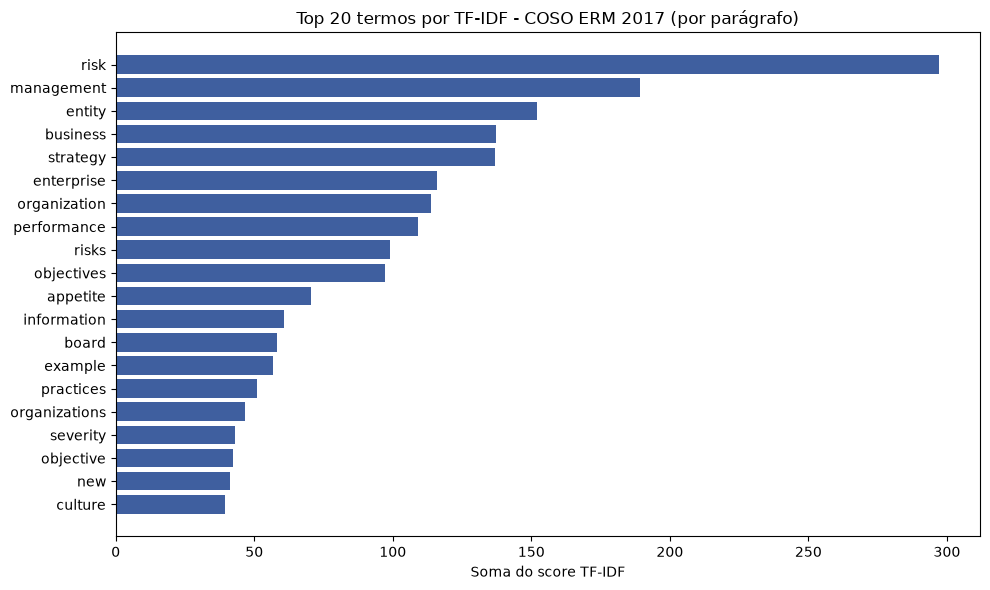

Parágrafos usados no TF-IDF: 5331


In [7]:
paragraphs = [p.strip() for p in clean.split("\n") if len(p.strip()) > 40]

vectorizer = TfidfVectorizer(stop_words="english", max_df=0.85, min_df=2)
matrix = vectorizer.fit_transform(paragraphs)
scores = matrix.sum(axis=0).A1
terms = vectorizer.get_feature_names_out()
ranked = sorted(zip(terms, scores), key=lambda x: x[1], reverse=True)[:20]

terms_, scores_ = zip(*ranked)
plt.figure(figsize=(10, 6))
plt.barh(terms_[::-1], scores_[::-1], color="#3f5f9f")
plt.title("Top 20 termos por TF-IDF - COSO ERM 2017 (por parágrafo)")
plt.xlabel("Soma do score TF-IDF")
plt.tight_layout()
plt.show()

print(f"Parágrafos usados no TF-IDF: {len(paragraphs)}")


## 6. Distribuição do tamanho das sentenças

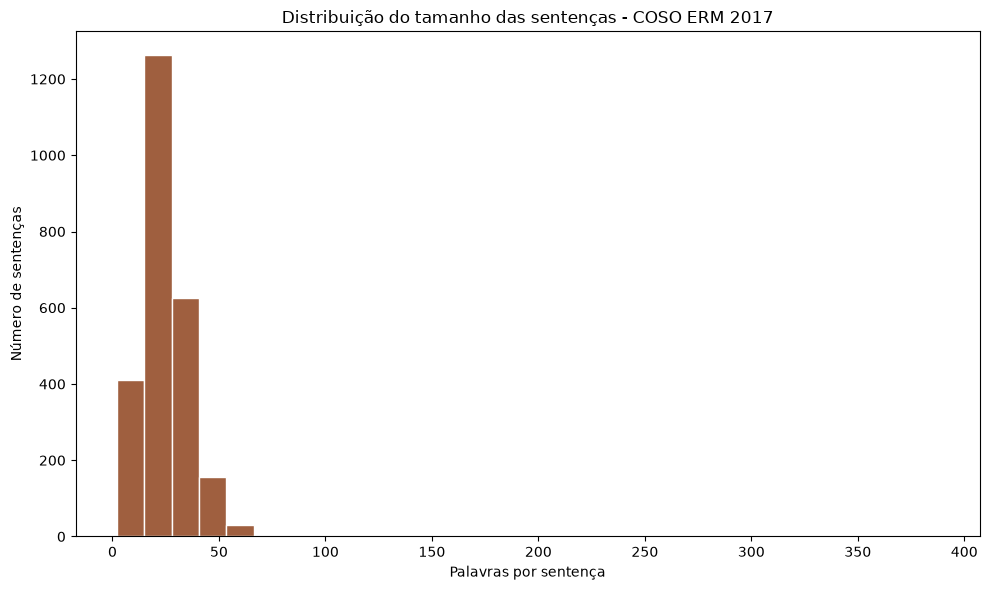

In [8]:
plt.figure(figsize=(10, 6))
plt.hist(words_per_sentence, bins=30, color="#9f5f3f", edgecolor="white")
plt.title("Distribuição do tamanho das sentenças - COSO ERM 2017")
plt.xlabel("Palavras por sentença")
plt.ylabel("Número de sentenças")
plt.tight_layout()
plt.show()


## 7. Estrutura temática: os 20 princípios do COSO ERM

Extração automática via expressões regulares sobre o texto já limpo, concatenando a
continuação do título quando ele é quebrado em duas linhas no documento original.


In [9]:
def extract_principles(text: str) -> dict:
    lines = text.split("\n")
    header_pattern = re.compile(r"^\s*Principle (\d+):\s*(.+)$")
    seen = {}

    for i, line in enumerate(lines):
        match = header_pattern.match(line)
        if not match:
            continue
        num = int(match.group(1))
        title = match.group(2).strip()

        if i + 1 < len(lines):
            nxt = lines[i + 1].strip()
            is_short_continuation = (
                nxt
                and len(nxt.split()) <= 6
                and not nxt.lower().startswith("principle")
                and not nxt[0].isdigit()
            )
            if is_short_continuation:
                title = f"{title} {nxt}"

        title = re.sub(r"\s+", " ", title).strip()
        if "principle" in title.lower():
            continue
        if num not in seen and 3 < len(title) < 80:
            seen[num] = title

    return dict(sorted(seen.items()))


principles = extract_principles(clean)
df_principles = pd.DataFrame(
    [{"principio": k, "titulo": v} for k, v in principles.items()]
)
print(f"Princípios identificados: {len(principles)} / 20")
df_principles


Princípios identificados: 20 / 20


,principio,titulo
0,1,Exercises Board Risk Oversight
1,2,Establishes Operating Structures
2,3,Defines Desired Culture
3,4,Demonstrates Commitment to Core Values
4,5,"Attracts, Develops, and Retains Capable Indivi..."
5,6,Analyzes Business Context
6,7,Defines Risk Appetite
7,8,Evaluates Alternative Strategies
8,9,Formulates Business Objectives
9,10,Identifies Risk


## 8. Conclusão da análise exploratória

- O corpus é um documento técnico extenso (~52 mil tokens alfabéticos), com baixa diversidade
  léxica (TTR ~0,07), típica de textos normativos que reutilizam o mesmo vocabulário
  especializado &ndash; o que reforça a adequação de uma abordagem de recuperação semântica
  (embeddings) em vez de busca literal por palavras-chave para o agente RAG planejado.
- A limpeza de texto (remoção de marcadores de página e correção do ligature "fi") foi essencial
  para não perder informação estrutural relevante, como os títulos dos próprios princípios do
  framework.
- A extração automática recuperou os 20 princípios oficiais do COSO ERM 2017, confirmando que o
  corpus preserva integralmente a estrutura temática necessária para fundamentar o agente
  especialista proposto.
